# Environment Setup

## Pip the necessary library

In [1]:
import os
dataset_path = "/kaggle/input/datasets/changchoufang/cv-hw1-data" # please to change to your path

In [2]:
# ===== (Optional) Install Dependencies =====
# Uncomment this if not running on kaggle or colab

# REQUIREMENT_PATH = os.path.join(dataset_path, "requirements.txt")
# !pip install -q -r {REQUIREMENT_PATH}

## Library import

In [3]:
# -*- coding: utf-8 -*-
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gc
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")


from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import timm
from tqdm import tqdm
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from sklearn.metrics import confusion_matrix

## Set the random seed

In [4]:
def set_seed(seed=42):
    import random, numpy as np, torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Training for the teacher model

## Training config setting

In [5]:
#########################################
# =============== setting ===============
#########################################

# datasetpath (please to change to your path)
train_path = os.path.join(dataset_path, "cv_hw1_data/data/train")
val_path   = os.path.join(dataset_path, "cv_hw1_data/data/val")
test_path  = os.path.join(dataset_path, "cv_hw1_data/data/test")

BATCH_SIZE = 64
EPOCHS = 3
LR = 1e-3 
NUM_CLASSES = 100
EARLY_STOPPING = 1000

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# augmentation hyperparameter
MIXUP_ALPHA = 0.4
AUG_PROB = 0.7

# the path of the model with the highest accuracy
BEST_MODEL_PATH = "best_teacher.pth"

# mixup or not
USE_MIXUP = True

## The function for model and dataset

In [6]:
def build_model():
  return timm.create_model(
    'seresnextaa201d_32x8d.sw_in12k_ft_in1k_384',
    pretrained=True,
    num_classes=NUM_CLASSES
  )

In [7]:
#########################################
# ========== Model Size =================
#########################################

def print_model_size(model):
    total = sum(p.numel() for p in model.parameters())
    print(f"Model Params: {total/1e6:.2f}M")

## Build the model using the function above

In [8]:
# Build model and ensure its model size

model = build_model()
print_model_size(model)

model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

Model Params: 147.55M


In [10]:
# Find the default transform and apply it to this dataset

data_config = timm.data.resolve_model_data_config(model)

train_transform = timm.data.create_transform(**data_config, is_training=True, auto_augment='rand-m9-mstd0.5', re_prob=0.25)
val_transform   = timm.data.create_transform(**data_config, is_training=False)

train_dataset = ImageFolder(train_path, transform=train_transform)
val_dataset   = ImageFolder(val_path, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))

Train images: 20724
Val images: 300


## The function of Training process

In [11]:
#########################################
# =============== Mixup =================
#########################################

def mixup(x, y, alpha):
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(DEVICE)
    return lam*x + (1-lam)*x[idx], y, y[idx], lam

In [12]:
#########################################
# ========== Gradual Unfreeze ===========
#########################################

def set_trainable_layers(model, stage, unfreeze_blocks=3):

    for p in model.parameters():
        p.requires_grad = False

    # ===== Stage 0: fc only =====
    if stage == 0:
        for p in model.fc.parameters():
            p.requires_grad = True

    # ===== Stage 1: layer4 + fc =====
    elif stage == 1:

        # fc 
        for p in model.fc.parameters():
            p.requires_grad = True

        # 開 layer 4 
        blocks = list(model.layer4.children())

        for block in blocks[-unfreeze_blocks:]: 
            for p in block.parameters(): 
                p.requires_grad = True

    # ===== Stage 2: layer3 (the last blocks) + layer4 + fc =====
    elif stage == 2:

        # fc 
        for p in model.fc.parameters():
            p.requires_grad = True

        # layer 4 
        blocks = list(model.layer4.children())

        for block in blocks[-3:]: 
            for p in block.parameters(): 
                p.requires_grad = True

        # layer 3
        blocks = list(model.layer3.children())

        for block in blocks[-1:]: 
            for p in block.parameters(): 
                p.requires_grad = True

In [13]:
#########################################
# ===== show trainable parameters  ======
#########################################

def print_trainable_layers(model):
    print("==== Trainable Layers ====")
    total = 0
    trainable = 0

    for name, p in model.named_parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()
            print(name)

    print(f"\nTrainable params: {trainable:,}")
    print(f"Total params: {total:,}")
    print(f"Trainable ratio: {trainable/total:.4f}")

In [14]:
#########################################
# ======== Training + Evaluation ========
#########################################

def train(model):
    
    PRINT = True # Debug flag for printing trainable layers

    # ===== Device Setup =====
    model = model.to(DEVICE)

    # ===== Loss Functions =====
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    
    # ===== Optimizer =====
    optimizer = optim.AdamW([
        {"params": model.fc.parameters(), "lr": LR},
        {"params": model.layer4.parameters(), "lr": LR * 0.3},
        {"params": model.layer3.parameters(), "lr": LR * 0.1},
    ])

    # ===== Learning Rate Scheduler =====
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=LR * 0.01
    )

    # ===== Mixed Precision Training =====
    scaler = torch.cuda.amp.GradScaler()

    # ===== Training Records =====
    best_acc = 0
    train_loss_list, val_loss_list = [], []
    train_acc_list, val_acc_list = [], []

    
    # =========================================
    # ============== Training Loop ============
    # =========================================
    for epoch in range(EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")

        # ===== Gradual Unfreezing Strategy =====
        if epoch < int(0.3 * EPOCHS):
            set_trainable_layers(model, 0)
        elif epoch < int(0.6 * EPOCHS):
            if not PRINT and epoch == int(0.3 * EPOCHS):
                print(f"[INFO] Unfreezing additional layers at epoch {epoch}")
                PRINT = True
            set_trainable_layers(model, 1)
        else:
            if not PRINT and epoch == int(0.6 * EPOCHS):
                print(f"[INFO] Further unfreezing at epoch {epoch}")
                PRINT = True
            set_trainable_layers(model, 1)

        # ===== Mixup Augmentation Schedule =====
        if not USE_MIXUP:
            aug_prob = 0
        else:
            if epoch < int(0.5 * EPOCHS):
                aug_prob = AUG_PROB
                alpha = MIXUP_ALPHA
                criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
            elif epoch < int(0.8 * EPOCHS):
                aug_prob = 0.2
                alpha = 0.2
                criterion = nn.CrossEntropyLoss()
            else:
                aug_prob = 0
                criterion = nn.CrossEntropyLoss()

        # ===== Debug: Print trainable layers =====
        if PRINT:
            print_trainable_layers(model)
            PRINT = False

        # =========================================
        # ============== Batch Loop ===============
        # =========================================
        model.train()
        running_loss, correct, total = 0, 0, 0
        pbar = tqdm(train_loader, desc="KD Training")

        for images, labels in pbar:
            
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast():
                
                # ===== (1) Apply Mixup =====
                if USE_MIXUP and np.random.rand() < aug_prob:
                    images, y_a, y_b, lam = mixup(images, labels, alpha)
                    is_mixed = True
                else:
                    lam = 1.0
                    is_mixed = False

                # ===== (2) Forward Pass =====
                logits = model(images)

                # ===== (3) Loss =====
                if is_mixed:
                    loss = lam * criterion(logits, y_a) + \
                                (1 - lam) * criterion(logits, y_b)
                else:
                    loss = criterion(logits, labels)

            # ===== Backpropagation =====
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # ===== Metrics =====
            running_loss += loss.item()
            _, pred = logits.max(1)
            total += labels.size(0)
            
            if is_mixed:
                correct += (lam * pred.eq(y_a).sum().item() + (1 - lam) * pred.eq(y_b).sum().item())
            else:
                correct += pred.eq(labels).sum().item()

            pbar.set_postfix({"loss": f"{loss.item():.4f}", "acc": f"{correct/total:.4f}"})

        scheduler.step()

        # ===== Training Statistics =====
        train_loss = running_loss / len(train_loader)
        train_acc = correct / total
        current_lr = optimizer.param_groups[0]['lr'] 

        train_loss_list.append(train_loss) 
        train_acc_list.append(train_acc)  
        
        # =========================================
        # ============== Validation ===============
        # =========================================
        model.eval()
        correct, total = 0, 0
        val_running_loss = 0

        ce_loss = nn.CrossEntropyLoss()

        with torch.no_grad():

            for images, labels in tqdm(val_loader, desc="Validation"):
                
                images, labels = images.to(DEVICE), labels.to(DEVICE)

                outputs = model(images)
                loss = ce_loss(outputs, labels)

                val_running_loss += loss.item()

                _, pred = outputs.max(1)
                total += labels.size(0)
                correct += pred.eq(labels).sum().item()

        val_loss = val_running_loss / len(val_loader)
        val_acc = correct / total

        val_loss_list.append(val_loss)
        val_acc_list.append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | LR: {current_lr:.6f}")

        # ===== Save Best Model =====
        if val_acc >= best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f">>> Save Best Model (Acc: {val_acc:.4f})")

    return model, train_loss_list, val_loss_list, train_acc_list, val_acc_list

## Run the train process

In [ ]:
model, train_loss, val_loss, train_acc, val_acc = train(model)

## Training Curves Visualization

In [ ]:
#########################################
# ====== Plot the training curve=========
#########################################

def plot_curve(train, val, title):

    plt.figure()
    plt.plot(train, label="train")
    plt.plot(val, label="val")
    plt.legend()
    plt.title(title)
    plt.show()

In [ ]:
plot_curve(train_loss, val_loss, "Loss")

In [ ]:
plot_curve(train_acc, val_acc, "Accuracy")

# Evaluate the best model by validation dataset

## The evaluation function

In [19]:
#########################################
# == Evaluation for validation dataset===
#########################################

def validate(model, val_loader, device):
    
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    val_running_loss = 0.0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)

            # loss
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()

            # prediction
            _, preds = outputs.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # accuracy
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = correct / total

    return val_loss, val_acc, all_preds, all_labels

In [20]:
#########################################
# ====== Plot the confusion matrix ======
#########################################

def plot_confusion_matrix(cm, title="Confusion Matrix", figsize=(12, 10)):
    plt.figure(figsize=figsize)
    sns.heatmap(cm, cmap="Blues")
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

## Run the evaluation process

In [21]:
# Load the best model from the best model checkpoint

model.load_state_dict(torch.load(BEST_MODEL_PATH))
model.to(DEVICE)
model.eval();

In [22]:
# run the evaluation
val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, DEVICE)

print(f"Val Loss: {val_loss:.4f}")
print(f"Val Acc: {val_acc:.4f}")

Validation: 100%|██████████| 5/5 [00:40<00:00,  8.16s/it]

Val Loss: 0.3106
Val Acc: 0.9367


## Plot Confusion Matrix on Validation Set

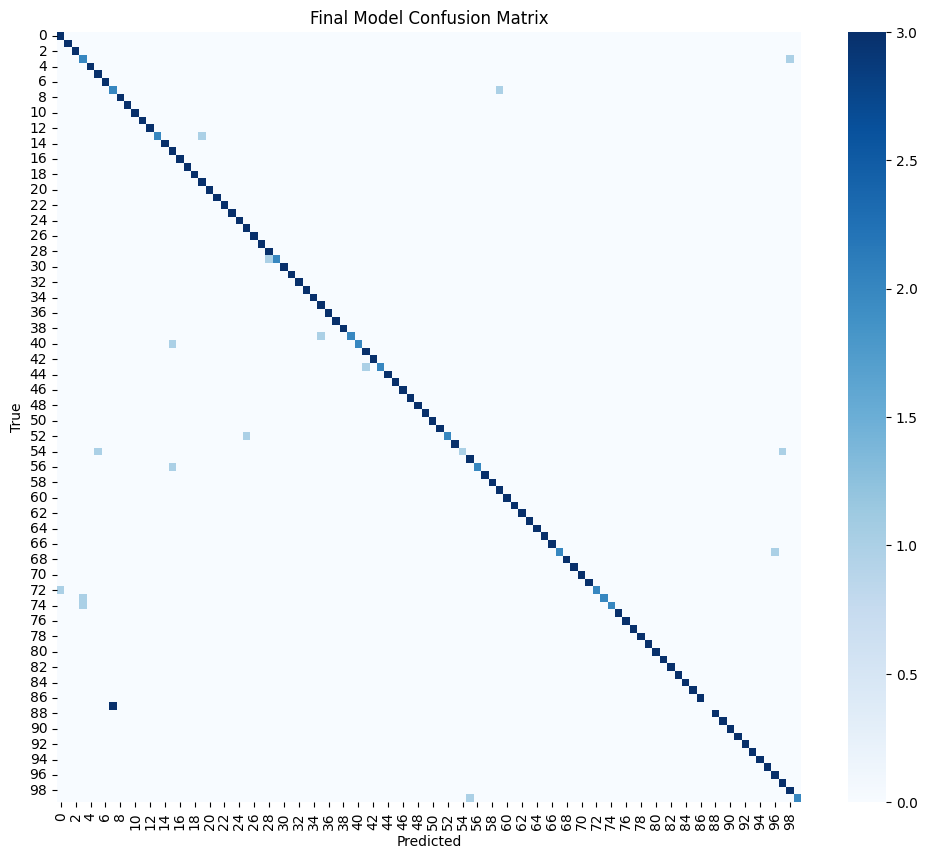

In [23]:
cm = confusion_matrix(val_labels, val_preds)
plot_confusion_matrix(cm, title="Final Model Confusion Matrix")